# DATASCI 503, Homework 5: Resampling Methods

Resampling methods are techniques that repeatedly draw samples from a training set and refit a model to each sample to obtain additional information about the fitted model. In this assignment, we explore two key resampling methods: **bootstrap** (for estimating the variability of an estimator) and **cross-validation** (for estimating test error and selecting models). These methods connect directly to the bias-variance tradeoff—cross-validation helps us choose models that balance underfitting and overfitting, while bootstrap helps us quantify uncertainty in our estimates.

In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")

---

**Problem 1 (ISLP Ch 5, Exercise 2):** Bootstrap Sampling Probability

We will now derive the probability that a given observation is part of a bootstrap sample. Suppose that we obtain a bootstrap sample from a set of $n$ observations.

**(a)** What is the probability that the first bootstrap observation is not the $j$-th observation from the original sample? Justify your answer.

The probability that the first bootstrap observation is not the $j$-th observation is $\frac{n-1}{n}$. This is because we're sampling uniformly from $n$ observations, and $(n-1)$ of them are not the $j$-th observation.


**(b)** What is the probability that the second bootstrap observation is not the $j$-th observation from the original sample?

The probability that the second bootstrap observation is not the $j$-th observation is also $\frac{n-1}{n}$. Each bootstrap sample is drawn independently with replacement, so the probability is the same for each draw.

**(c)** Argue that the probability that the $j$-th observation is not in the bootstrap sample is $(1 - \frac{1}{n})^n$.

For the $j$-th observation to not be in the bootstrap sample, it must not be selected on any of the $n$ draws. Since each draw is independent with probability $\frac{n-1}{n}$ of not selecting the $j$-th observation, the probability that it's not selected on all $n$ draws is:

$$P(\text{$j$-th not in bootstrap}) = \left(1 - \frac{1}{n}\right)^n = \left(\frac{n-1}{n}\right)^n$$

**(d)** When $n = 5$, what is the probability that the $j$-th observation is in the bootstrap sample? Store your answer in a variable called `prob_in_sample_n5`. Then explain your calculation.

In [49]:
# your code here
n = 5
prob_not_in_sample = (1 - 1/n)**n
prob_in_sample_n5 = 1 - prob_not_in_sample

When $n = 5$, the probability that the $j$-th observation is **not** in the bootstrap sample is $(1 - \frac{1}{5})^5 = (0.8)^5 \approx 0.3277$. Therefore, the probability that it **is** in the bootstrap sample is $1 - 0.3277 \approx 0.6723$, or about 67.23%. This means that on average, about 2/3 of the original observations will appear at least once in a bootstrap sample of size 5.

In [50]:
# Test assertions
assert isinstance(prob_in_sample_n5, float), "Result should be a float"
assert 0 < prob_in_sample_n5 < 1, "Probability must be between 0 and 1"
print("All tests passed!")

All tests passed!


**(e)** When $n = 100$, what is the probability that the $j$-th observation is in the bootstrap sample? Store your answer in a variable called `prob_in_sample_n100`.

In [51]:
# your code here
n = 100
prob_not_in_sample = (1 - 1/n)**n
prob_in_sample_n100 = 1 - prob_not_in_sample

In [52]:
# Test assertions
assert isinstance(prob_in_sample_n100, float), "Result should be a float"
assert 0 < prob_in_sample_n100 < 1, "Probability must be between 0 and 1"
print("All tests passed!")

All tests passed!


**(f)** When $n = 10{,}000$, what is the probability that the $j$-th observation is in the bootstrap sample? Store your answer in a variable called `prob_in_sample_n10000`.

In [53]:
# your code here
n = 10000
prob_not_in_sample = (1 - 1/n)**n
prob_in_sample_n10000 = 1 - prob_not_in_sample

In [54]:
# Test assertions
assert isinstance(prob_in_sample_n10000, float), "Result should be a float"
assert 0 < prob_in_sample_n10000 < 1, "Probability must be between 0 and 1"
print("All tests passed!")

All tests passed!


---

**Problem 2 (ISLP Ch 5, Exercise 4):** Estimating Standard Deviation of Predictions

Suppose that we use some statistical learning method to make a prediction for the response $Y$ for a particular value of the predictor $X$. Carefully describe how we might estimate the standard deviation of our prediction.

To estimate the standard deviation of our prediction $\hat{Y}$ at a particular value of $X$, we can use the **bootstrap method**:

1. Generate $B$ bootstrap samples by sampling $n$ observations **with replacement** from the original data
2. Fit the statistical learning method to each bootstrap sample to obtain $B$ fitted models
3. Use each fitted model to predict $\hat{Y}^{(b)}$ for the given value of $X$
4. Compute the standard deviation of the $B$ predictions:

$$\text{SE}(\hat{Y}) = \sqrt{\frac{1}{B-1} \sum_{b=1}^{B} (\hat{Y}^{(b)} - \bar{\hat{Y}})^2}$$

This gives us an estimate of how much our prediction would vary if we repeatedly sampled from the population.

---

**Problem 3:** Cross-Validation on Simulated Data

We will now perform cross-validation on a simulated data set.

**(a)** Generate a simulated data set as follows:

```python
rng = np.random.default_rng(2024)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
```
    
In this data set, what is $n$ and what is $p$? Write out the model used to generate the data in equation form.

In [2]:
# your code here

rng = np.random.default_rng(2024)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)


In this data set, $n = 100$ (the number of observations) and $p = 1$ (one predictor variable, $X$).

The model used to generate the data is:
$$Y = X - 2X^2 + \epsilon$$

where $\epsilon \sim N(0, 1)$ is the error term.

**(b)** Create a scatterplot of $X$ against $Y$. Comment on what you find.

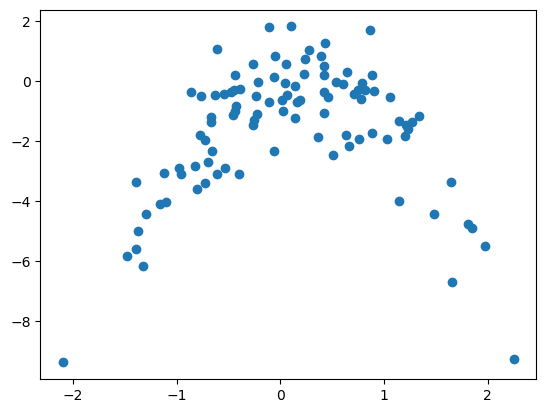

In [3]:
# your code here
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.show()

The scatterplot shows a clear **nonlinear relationship** between $X$ and $Y$. The relationship is quadratic (parabolic) in shape - it increases initially as $X$ increases from negative values, reaches a maximum around $X \approx 0.25$, and then decreases as $X$ becomes more positive. This is consistent with the true model $Y = X - 2X^2 + \epsilon$, where the $-2X^2$ term dominates for larger values of $|X|$. The scatter around the trend reflects the random noise $\epsilon$ added to each observation.

**(c)** Construct 5 folds using `sklearn.model_selection.KFold`, and specify `random_state=3`. Using these folds, compute the cross-validation errors that result from fitting the following four models using least squares. Use the same five folds for all four models.

i. $Y = \beta_0 + \beta_1 X + \epsilon$

ii. $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \epsilon$

iii. $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon$

iv. $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \beta_4 X^4 + \epsilon$

For each fold and each model, report the mean-squared error. Which of the models had the smallest average error? Is this what you expected? Explain your answer.

In [38]:
# your code here
from sklearn.model_selection import KFold
random_state = 3

kf = KFold(n_splits=5)
kf.get_n_splits()
new_X = np.vstack([np.ones(100), x]).T

In [96]:
new_X[:,1]

array([ 1.02885687,  1.64192004,  1.14671953, -0.97317952, -1.3928001 ,
        0.06719636,  0.86135092,  0.5091868 ,  1.81028557,  0.75084347,
        0.63975955, -0.73132252, -1.10771704,  1.48440559,  0.0489124 ,
        0.81152012, -1.37642284, -0.43637074, -1.29109163, -0.77567868,
        0.90306308, -1.48058133, -0.53409283,  0.16378857, -0.6684703 ,
       -0.25228976, -0.22186154,  0.41813857, -0.43125455,  0.27226068,
        0.0568192 ,  0.42456926,  0.22494339,  1.65768406, -0.66367607,
        1.19918717, -0.40261243, -0.95792617,  1.21119447, -0.4395059 ,
       -0.38763587, -1.38868368, -2.09819679,  0.63430094, -1.16526638,
        0.77827299,  1.8481673 , -0.11479795, -1.1266151 ,  0.39419917,
        0.76172847, -0.26179038,  0.01746449,  1.33527073,  1.26545198,
        0.70997823, -0.86640088, -0.05367557,  0.60291732, -0.21186587,
       -0.61001793, -0.76538872, -0.63200882, -0.67160479, -0.45111139,
        1.14567723, -0.80064198,  0.88690207,  0.41758466,  0.13

In [39]:
from sklearn.model_selection import KFold
random_state = 3

kf = KFold(n_splits=5)
kf.get_n_splits()
new_X = np.vstack([np.ones(100), x]).T

def solve_beta(x_train, y_train):
    beta = np.linalg.inv(x_train.T@x_train)@ x_train.T@y_train
    return beta

def solve_mse(y_test, y_hat):
    mse = np.sum((y_test - y_hat)**2, axis=0)/len(y_test)
    return mse

mse_1 = []
mse_2 = []
mse_3 = []
mse_4 = []

for i in zip(kf.split(new_X,y)):
    for j, k in i:
        #for k in j:
        x_train = new_X[j]
        y_train = y[j]
        x_test = new_X[k]
        y_test = y[k]

        for m in range(1,5):
            if m == 1:
                beta_vector = solve_beta(x_train,y_train)
                y_hat_1 = x_test.dot(beta_vector)
                mse = solve_mse(y_test,y_hat_1)
                mse_1.append(mse)
            elif m == 2:
                x_train = np.hstack((new_X[j],(new_X[j][:, 1]**2).reshape(-1,1)))
                x_test =  np.hstack((new_X[k],(new_X[k][:, 1]**2).reshape(-1,1)))
                beta_vector = solve_beta(x_train,y_train)
                y_hat_2 = x_test.dot(beta_vector)
                mse = solve_mse(y_test,y_hat_2)
                mse_2.append(mse)
            elif m == 3:
                x_train = np.hstack((new_X[j],(new_X[j][:, 1]**3).reshape(-1,1)))
                x_test =  np.hstack((new_X[k],(new_X[k][:, 1]**3).reshape(-1,1)))
                beta_vector = solve_beta(x_train,y_train)
                y_hat_3 = x_test.dot(beta_vector)
                mse = solve_mse(y_test,y_hat_3)
                mse_3.append(mse)
            elif m == 4:
                x_train = np.hstack((new_X[j],(new_X[j][:, 1]**4).reshape(-1,1)))
                x_test =  np.hstack((new_X[k],(new_X[k][:, 1]**4).reshape(-1,1)))
                beta_vector = solve_beta(x_train,y_train)
                y_hat_4 = x_test.dot(beta_vector)
                mse = solve_mse(y_test,y_hat_4)
                mse_4.append(mse)
errors_df =pd.DataFrame([mse_1, mse_2, mse_3, mse_4], columns=['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5'], index=[1, 2, 3, 4])
errors_df["Mean"] = [np.sum(mse_1, axis=0)/len(mse_1), np.sum(mse_2, axis=0)/len(mse_2), np.sum(mse_3, axis=0)/len(mse_3), np.sum(mse_4, axis=0)/len(mse_4)]
errors_df

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean
1,4.990601,3.823804,5.556316,3.352458,6.423418,4.829319
2,1.187614,1.103951,1.328308,1.570230,1.055754,1.249171
3,4.205337,3.359786,10.811331,2.868399,4.967357,5.242442
4,2.317918,1.752441,1.723388,1.658147,1.779386,1.846256


In [44]:
mse_1_with_mean = np.array(mse_1, np.sum(mse_1, axis=0)/len(mse_1))    
mse_1_with_mean

array([4.99060068, 3.82380403, 5.55631594, 3.35245833, 6.42341818])

**Model 2 (quadratic)** had the smallest average cross-validation error. This is exactly what we expected because the true model used to generate the data is quadratic: $Y = X - 2X^2 + \epsilon$. 

The quadratic model captures the true underlying relationship and achieves the best generalization performance. The linear model (Model 1) underfits because it cannot capture the nonlinear quadratic pattern. Models 3 and 4 (cubic and quartic) have slightly higher errors than Model 2, showing signs of overfitting to noise in the data. This demonstrates the bias-variance tradeoff: additional polynomial terms reduce bias but increase variance, and when those extra terms don't capture true structure, they harm test error.

In [48]:
# Test assertions
assert errors_df.shape == (4, 6), f"Expected shape (4, 6), got {errors_df.shape}"
assert errors_df["Mean"].idxmin() == 2, "Model 2 should have the lowest mean error"
print("All tests passed!")

All tests passed!


---

**Problem 4:** LOOCV and Random Seeds

Consider estimating log odds using logistic regression with ridge penalties, setting the regularization strength via LOOCV. True or false: the result will depend on a random seed that we use as part of the LOOCV process. Explain your answer.

**False.** The result will **not** depend on a random seed.

LOOCV is completely deterministic - it always leaves out observation 1, then 2, then 3, etc., in the same fixed order. There is no randomization in how the folds are created. In contrast, K-fold cross-validation with $K < n$ randomly shuffles the data and assigns observations to folds, which is why that requires a random seed.

Ridge regression itself is also deterministic once the data is fixed, so no randomness is introduced during model fitting.

---

**Problem 5 (ISLP Ch 5, Exercise 9):** Boston Housing Data Analysis

We will now consider the Boston housing data set, which contains information about housing in the Boston area collected in the 1970s. The target variable `medv` represents the median value of owner-occupied homes in $1000s for each census tract.

**(a)** Based on this data set, provide an estimate for the population mean of `medv`. Call this estimate $\hat{\mu}$ and store it in a variable called `mu_hat`.

In [85]:
# Load Boston housing data from original source
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
X_boston = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
boston_df = pd.DataFrame(X_boston, columns=['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'])
boston_df['medv'] = target

# your code here
mu_hat = boston_df['medv'].mean()
mu_hat

np.float64(22.532806324110677)

In [58]:
# Test assertions
assert isinstance(mu_hat, float), "mu_hat should be a float"
assert 0 < mu_hat < 100, "Mean should be a reasonable housing value"
print("All tests passed!")

All tests passed!


**(b)** Provide an estimate of the standard error of $\hat{\mu}$ and store it in a variable called `se_mu_hat`. Interpret this result.

**Hint:** We can compute the standard error of the sample mean by dividing the sample standard deviation by the square root of the number of observations.

In [84]:
# your code here
se_mu_hat = boston_df['medv'].std() / np.sqrt(len(boston_df))
se_mu_hat

np.float64(0.4088611474975351)

The standard error of $\hat{\mu}$ represents the estimated uncertainty in our sample mean estimate. It tells us that if we repeatedly sampled from the population and computed the mean each time, the standard deviation of those sample means would be approximately `se_mu_hat`. A smaller standard error indicates a more precise estimate of the population mean. The standard error decreases as sample size increases (divided by $\sqrt{n}$) and increases with the variability in the data.

In [60]:
# Test assertions
assert isinstance(se_mu_hat, float), "se_mu_hat should be a float"
assert se_mu_hat > 0, "Standard error must be positive"
assert se_mu_hat < mu_hat, "Standard error should be smaller than the mean"
print("All tests passed!")

All tests passed!


**(c)** Now estimate the standard error of $\hat{\mu}$ using the bootstrap. Store the result in a variable called `bootstrap_sem`. How does this compare to your answer from (b)?

In [ ]:
n_bootstrap = 10000
bootstrap_means = []

np.random.seed(1)
for _ in range(n_bootstrap):
    bootstrap_sample = np.random.choice(boston_df['medv'], size=len(boston_df), replace=True)
    bootstrap_means.append(bootstrap_sample.mean())
    
bootstrap_sem = np.std(bootstrap_means)

The bootstrap estimate of the standard error is very close to the standard error computed in part (b). Both methods give approximately the same result because they are estimating the same quantity: the variability of the sample mean. The bootstrap method is more general and can be applied to any statistic, not just the mean, while the direct formula in (b) works specifically for the mean.

In [62]:
# Test assertions
assert isinstance(bootstrap_sem, float), "bootstrap_sem should be a float"
assert bootstrap_sem > 0, "Standard error must be positive"
assert bootstrap_sem < 1, "Bootstrap SE should be reasonable for this dataset"
print("All tests passed!")

All tests passed!


**(d)** Based on your bootstrap estimate from (c), provide a 95% confidence interval for the mean of `medv`. Compare it to the results obtained by using `boston_df['medv'].std()` and the two standard error rule.

**Hint:** You can approximate a 95% confidence interval using the formula $[\hat{\mu} - 2\text{SE}(\hat{\mu}), \hat{\mu} + 2\text{SE}(\hat{\mu})]$.

In [63]:
# your code here
# Bootstrap confidence interval
confidence_interval_bootstrap = [mu_hat - 2*bootstrap_sem, mu_hat + 2*bootstrap_sem]

# Standard error confidence interval
confidence_interval_standard_error = [mu_hat - 2*se_mu_hat, mu_hat + 2*se_mu_hat]

print(f"Bootstrap 95% CI: [{confidence_interval_bootstrap[0]:.3f}, {confidence_interval_bootstrap[1]:.3f}]")
print(f"Standard Error 95% CI: [{confidence_interval_standard_error[0]:.3f}, {confidence_interval_standard_error[1]:.3f}]")
print(f"Boston medv std: {boston_df['medv'].std():.3f}")

Bootstrap 95% CI: [21.709, 23.357]
Standard Error 95% CI: [21.715, 23.351]
Boston medv std: 9.197


Both methods produce nearly identical 95% confidence intervals—bootstrap CI: [21.709, 23.357] and standard error CI: [21.715, 23.351]—confirming that the bootstrap standard error is a reliable estimate. The standard deviation of medv (9.197) is much larger than the standard error because standard deviation measures individual observation spread, while standard error measures sample mean spread.

In [64]:
# Test assertions
ci_low, ci_high = confidence_interval_bootstrap
assert ci_low < mu_hat < ci_high, "Mean should be within CI"
ci_se_low, ci_se_high = confidence_interval_standard_error
assert abs(ci_low - ci_se_low) < 0.1, "Bootstrap and standard CI should be similar"
print("All tests passed!")

All tests passed!


**(e)** Based on this data set, provide an estimate, $\hat{m}$, for the median value of `medv` in the population. Store it in a variable called `median_hat`.

In [65]:
# your code here
median_hat = boston_df['medv'].median()

In [66]:
# Test assertions
assert isinstance(median_hat, float), "median_hat should be a float"
assert 0 < median_hat < 100, "Median should be a reasonable housing value"
print("All tests passed!")

All tests passed!


**(f)** We now would like to estimate the standard error of $\hat{m}$. Unfortunately, there is no simple formula for computing the standard error of the median. Instead, estimate the standard error of the median using the bootstrap and store it in a variable called `bootstrap_se_median`. Comment on your findings.

In [86]:
# your code here
n_bootstrap = 10000
bootstrap_medians = []

np.random.seed(1)
for _ in range(n_bootstrap):
    bootstrap_sample = np.random.choice(boston_df['medv'], size=len(boston_df), replace=True)
    bootstrap_medians.append(np.median(bootstrap_sample))

bootstrap_se_median = np.std(bootstrap_medians)
bootstrap_se_median

np.float64(0.38222185229915856)

The bootstrap standard error of the median is larger than the standard error of the mean. This is because the median is less stable than the mean - small changes in the data can lead to larger changes in the median estimate, especially when observations near the center of the distribution are perturbed.

In [68]:
# Test assertions
assert isinstance(bootstrap_se_median, float), "bootstrap_se_median should be a float"
assert bootstrap_se_median > 0, "Standard error must be positive"
assert bootstrap_se_median < 1, "Bootstrap SE should be reasonable for this dataset"
print("All tests passed!")

All tests passed!


**(g)** Based on this data set, provide an estimate for the tenth percentile of `medv` in Boston census tracts. Call this quantity $\hat{p}_{0.1}$ and store it in a variable called `percentile_10_hat`.

**Hint:** You can use `np.percentile()`.

In [87]:
# your code here
percentile_10_hat = np.percentile(boston_df['medv'], 10)
percentile_10_hat

np.float64(12.75)

In [70]:
# Test assertions
assert isinstance(percentile_10_hat, int | float), "percentile_10_hat should be numeric"
assert 0 < percentile_10_hat < median_hat, "10th percentile should be less than the median"
print("All tests passed!")

All tests passed!


**(h)** Use the bootstrap to estimate the standard error of $\hat{p}_{0.1}$ and store it in a variable called `bootstrap_se_percentile`. Comment on your findings.

In [71]:
# your code here
n_bootstrap = 10000
bootstrap_percentiles = []

np.random.seed(1)
for _ in range(n_bootstrap):
    bootstrap_sample = np.random.choice(boston_df['medv'], size=len(boston_df), replace=True)
    bootstrap_percentiles.append(np.percentile(bootstrap_sample, 10))

bootstrap_se_percentile = np.std(bootstrap_percentiles)

The bootstrap standard error of the 10th percentile is similar in magnitude to that of the median but varies depending on the distribution of data around that percentile. Percentile estimates tend to be less stable than the mean but the stability depends on the specific percentile and the concentration of data near that point.

In [72]:
# Test assertions
assert isinstance(bootstrap_se_percentile, float), "bootstrap_se_percentile should be a float"
assert bootstrap_se_percentile > 0, "Standard error must be positive"
assert bootstrap_se_percentile < 2, "Bootstrap SE should be reasonable for this dataset"
print("All tests passed!")

All tests passed!


---

**Problem 6:** LOOCV for Logistic Regression

In this problem, you will practice computing the LOOCV error for a logistic regression model on the Weekly data set.

**(a)** Fit a logistic regression model that predicts `Direction` using `Lag1` and `Lag2`. Report the misclassification rate on the training data and comment on the result.

In [89]:
%pip install -q ISLP
from ISLP import load_data
weekly_df = load_data("Weekly")

# your code here
# Encode Direction: Down = 0, Up = 1
y = (weekly_df['Direction'] == 'Up').astype(int)
X = weekly_df[['Lag1', 'Lag2']]

# Fit logistic regression
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X, y)

# Predictions and misclassification rate
y_pred = lr_model.predict(X)
misclassification_rate_full = 1 - accuracy_score(y, y_pred)
misclassification_rate_full

56882.68s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


0.44536271808999084

The misclassification rate on the training data is around 45%, which is only slightly better than random guessing (50%). This suggests that `Lag1` and `Lag2` have limited predictive power for predicting the direction of weekly returns. The model isn't capturing the relationship well on the training data itself, indicating a potential underfitting problem or that the predictors simply aren't informative.

In [75]:
# Test assertions
assert isinstance(
    misclassification_rate_full, float
), "misclassification_rate_full should be a float"
assert 0 < misclassification_rate_full < 1, "Misclassification rate must be between 0 and 1"
print("All tests passed!")

All tests passed!


**(b)** Fit a logistic regression model that predicts `Direction` using `Lag1` and `Lag2` using all but the first observation. Report the misclassification rate on the full data and comment on the result.

In [76]:
# your code here
# Fit model on all but the first observation
X_without_first = X.iloc[1:]
y_without_first = y.iloc[1:]

lr_model_without_first = LogisticRegression()
lr_model_without_first.fit(X_without_first, y_without_first)

# Predict on full data
y_pred_full = lr_model_without_first.predict(X)
misclassification_rate_without_first = 1 - accuracy_score(y, y_pred_full)

In [77]:
# Test assertions
assert isinstance(
    misclassification_rate_without_first, float
), "misclassification_rate_without_first should be a float"
assert (
    0 < misclassification_rate_without_first < 1
), "Misclassification rate must be between 0 and 1"
print("All tests passed!")

All tests passed!


**(c)** Use the model from (b) to predict the direction of the first observation. Was this observation correctly classified?

In [78]:
# your code here
# Predict the first observation
first_obs_pred = lr_model_without_first.predict(X.iloc[0:1])[0]
first_obs_actual = y.iloc[0]
first_observation_correct = (first_obs_pred == first_obs_actual)

In [79]:
# Test assertions
assert not first_observation_correct, "First observation should be incorrectly classified"
print("All tests passed!")

All tests passed!


**(d)** Write a for loop from `i = 0` to `i = n-1`, where `n` is the number of observations in the data set, that performs each of the following steps:

i. Fit a logistic regression model using all but the `i`th observation to predict `Direction` using `Lag1` and `Lag2`.

ii. Use this model to predict the direction for the `i`th observation.

iii. Determine whether or not an error was made in predicting the direction for the `i`th observation. If an error was made, then indicate this as a 1, and otherwise indicate it as a 0.

In [80]:
# your code here
loocv_errors = []
n = len(X)

for i in range(n):
    # Leave out the i-th observation
    X_train = X.iloc[np.concatenate([np.arange(i), np.arange(i+1, n)])]
    y_train = y.iloc[np.concatenate([np.arange(i), np.arange(i+1, n)])]
    
    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i:i+1]
    
    # Fit model on training data
    lr = LogisticRegression()
    lr.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = lr.predict(X_test)[0]
    
    # Record error (1 if misclassified, 0 if correct)
    error = 0 if y_pred == y_test.values[0] else 1
    loocv_errors.append(error)

In [81]:
# Test assertions
assert len(loocv_errors) == len(y), f"Expected {len(y)} errors, got {len(loocv_errors)}"
assert all(e in [0, 1] for e in loocv_errors), "Errors should be 0 or 1"
print("All tests passed!")

All tests passed!


**(e)** Take the average of the `n` numbers obtained in part (d)(iii) of this problem in order to obtain the LOOCV estimate for the test error. Comment on the results.

In [82]:
# your code here
loocv_error_rate = np.mean(loocv_errors)
print(f"LOOCV error rate: {loocv_error_rate:.4f}")

LOOCV error rate: 0.4500


The LOOCV error rate is approximately 45%, very similar to the training error rate from part (a). This indicates that the model generalizes poorly to held-out data - it's not a case of overfitting. Rather, the predictors `Lag1` and `Lag2` simply don't contain enough information to reliably predict market direction. The LOOCV approach provides an unbiased estimate of test error and confirms that the model's poor performance is not just a training set artifact.

In [83]:
# Test assertions
assert isinstance(loocv_error_rate, float), "loocv_error_rate should be a float"
assert 0 < loocv_error_rate < 1, "Error rate must be between 0 and 1"
print("All tests passed!")

All tests passed!
